In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import Planck15
from astropy.table import Table
from astropy import constants as const
from astropy import units as u
from glob import glob
import h5py 
from timeit import default_timer as timer
import multiprocess

import os, sys
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=64"
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' # for GPU 

from jax import config
config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax._src.third_party.scipy.interpolate import RegularGridInterpolator as jax_RegularGridInterpolator
from jax import jit, grad, vmap, pmap, debug, jvp, vjp, jacrev, jacfwd, make_jaxpr, hessian, value_and_grad
from jax_cosmo.scipy.interpolate import InterpolatedUnivariateSpline

from scipy.interpolate import InterpolatedUnivariateSpline as scipy_InterpolatedUnivariateSpline
from scipy.ndimage import gaussian_filter1d

from jax.experimental.ode import odeint
from jax.lax import fori_loop, while_loop
from jax.scipy.integrate import trapezoid

from diffrax import diffeqsolve, ODETerm, PIDController, SaveAt, Kvaerno3, Bosh3, Dopri5, Tsit5, DirectAdjoint, RecursiveCheckpointAdjoint, BacksolveAdjoint

from diffrax import backward_hermite_coefficients, CubicInterpolation

from functools import partial

from jax.random import PRNGKey, key

import numpyro
import numpyro.distributions as dist
from numpyro.examples.datasets import LYNXHARE, load_dataset
from numpyro.infer import MCMC, NUTS, Predictive, AIES, ESS

from jax.experimental import mesh_utils
from jax.experimental.shard_map import shard_map
from jax.sharding import Mesh, PartitionSpec, PositionalSharding, NamedSharding

import optax

import arviz as az
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth, ChainConfig
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec

plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

In [2]:
multiprocess.cpu_count() # for CPUs on GPU node

64

In [3]:
import jax
print(jax.__version__)
print(jax.devices())
print(jax.local_device_count())

import pprint
for dev in jax.devices():
    print(dev.device_kind)
    pprint.pprint(dev.memory_stats() )

0.4.31
[CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9), CpuDevice(id=10), CpuDevice(id=11), CpuDevice(id=12), CpuDevice(id=13), CpuDevice(id=14), CpuDevice(id=15), CpuDevice(id=16), CpuDevice(id=17), CpuDevice(id=18), CpuDevice(id=19), CpuDevice(id=20), CpuDevice(id=21), CpuDevice(id=22), CpuDevice(id=23), CpuDevice(id=24), CpuDevice(id=25), CpuDevice(id=26), CpuDevice(id=27), CpuDevice(id=28), CpuDevice(id=29), CpuDevice(id=30), CpuDevice(id=31), CpuDevice(id=32), CpuDevice(id=33), CpuDevice(id=34), CpuDevice(id=35), CpuDevice(id=36), CpuDevice(id=37), CpuDevice(id=38), CpuDevice(id=39), CpuDevice(id=40), CpuDevice(id=41), CpuDevice(id=42), CpuDevice(id=43), CpuDevice(id=44), CpuDevice(id=45), CpuDevice(id=46), CpuDevice(id=47), CpuDevice(id=48), CpuDevice(id=49), CpuDevice(id=50), CpuDevice(id=51), CpuDevice(id=52), CpuDevice(id=53), CpuDevice(id=54), CpuDevice(id

In [67]:
### function that returns trace_df and final point estimate +/- fisher sigma for each of the 3 constraints
def read_mocks(mocknum):

    # TO DO: have constraint_flag be an input (compatible with multiprocess.map)
    fname = os.path.join(output_path,'outputs','mock%s_%s.npz'%(mocknum,constraint_flag))

    npz = jnp.load(fname,allow_pickle=True)

    # best adam parameters
    mus = npz['theta_map']
    
    ### sqrt of inverse Fisher matrix diagonals
    Finv = npz['Finv_adam']

    # May 22: deal with when Finv_adam = nan due to saddle
    ### June 3 -- add correlation coefficient for off-diagonal degeneracies of Fisher
    try:
        sigmas = jnp.sqrt(jnp.diag(Finv))
        corr_matrix = Finv / jnp.outer(sigmas,sigmas)
    except:
        sigmas = jnp.full((Npars,), jnp.nan)
        corr_matrix = jnp.full((Npars, Npars), jnp.nan)        

    # mock truth parameter values
    truths = npz['free_params_arr']

    ### sqrt diagonals of TRUE Fisher -- this is what we normalize theta_map-theta_true by 
    Finv_true = npz['Finv_true']

    try: 
        sigmas_true = jnp.sqrt(jnp.diag(Finv_true))
    except:
        sigmas_true = jnp.full((Npars,), jnp.nan)

    # July 8 -- ratio of best loss from adam / true loss, note this includes saddles but we can filter later 
    # actually since these are negative log-posteriors, makes more sense to subtract best minus true 
    loss_ratio = float(npz['best_adam_loss']) - float(npz['true_loss'])

    # filter here -- set loss ratio to nan for saddles for plotting/nan-averaging purposes
    if not jnp.all(jnp.isfinite(sigmas)):
        loss_ratio = jnp.nan
    
    # return trace_dfs, mus, sigmas, truths
    return mus, sigmas, truths, sigmas_true, corr_matrix, loss_ratio


In [68]:
### glob output files

output_path = '/mnt/ceph/users/vpandya/sapphire_outputs'

# how many mocks we ran per flag
mocknums = jnp.arange(100)

# smhm-only, smhm+fgas, smhm+fgas+mzr 
constraint_flags = ['100','110','111']
constraint_labels = [r'only $M_*/M_h$',r'with ISM $f_{\rm gas}$',r'with stellar MZR']
constraint_colors = ['teal','indigo','orange']

# free parameter names
# TO DO: this needs to be automated / saved in npz file
par_labels = [r'$A_M$',r'$\alpha_M^0$',r'$A_E$',r'$\alpha_E^0$',r'$A_{\rm SF}$',r'$\alpha_{\rm SF}^0$',r'$A_Z$',r'$\alpha_Z^0$']
Npars = len(par_labels)


In [69]:
## test single 

constraint_flag = '100'

read_mocks(0)

(array([-1.16838121e+00, -1.69509643e+00, -1.04067432e+00, -5.20988768e-01,
         1.54361847e-03, -6.95562291e-01, -8.92450763e-01, -1.99742135e+00]),
 Array([nan, nan, nan, nan, nan, nan, nan, nan], dtype=float64),
 array([-1.27846936, -1.77876528, -1.11253865, -0.67127064,  0.46688258,
        -0.0725218 , -0.77154623, -1.82730977]),
 Array([nan, nan, nan, nan, nan, nan, nan, nan], dtype=float64),
 Array([[nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan]], dtype=float64),
 nan)

In [70]:
### loop over and store outputs with multiprocess

constraint_results = []
constraint_corrs = []
constraint_Lratios = [] # loss ratios best_adam/true_loss

tstart0 = timer()

for constraint_flag in constraint_flags:
    tstart = timer()
    with multiprocess.Pool(40) as pool:
        # shape (Nmocks, 3 [mus/sigmas/truths], Nparams)
        
        out_constraint = pool.map(read_mocks, mocknums)
        constraint_results.append(np.asarray([out_constraint[i][:4] for i in mocknums]))
        constraint_corrs.append(np.asarray([out_constraint[i][4] for i in mocknums]))
        constraint_Lratios.append(np.asarray([out_constraint[i][5] for i in mocknums]))
        
    print('finished constraint_flag=%s in %.3f sec'%(constraint_flag,timer()-tstart))

print('finished all runs in %.3f sec'%(timer()-tstart0))


/mnt/home/vpandya/miniconda3/envs/jaxclone/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=100 in 0.463 sec


/mnt/home/vpandya/miniconda3/envs/jaxclone/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/jaxclone/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=110 in 0.458 sec


/mnt/home/vpandya/miniconda3/envs/jaxclone/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=111 in 0.444 sec
finished all runs in 1.365 sec


In [71]:


# TO DO: generalize this to operate over arbitrary number of params (columns) and constraints (rows)
def predicted_vs_true_parameters(constraint_results,constraint_labels,constraint_colors):

    # adapted from https://github.com/maho3/ltu-ili/blob/44522f47c37f69b74313e80c7f1f04600472d116/ili/validation/metrics.py#L471
    
    # TO DO: generalize this based on params_bounds from config.yaml
    axlims8 = {0:(-2.1,1.1),1:(-2.1,0.1),2:(-2.1,0.1),3:(-2.1,0.1),4:(-0.1,1.2),5:(-2.1,0.1),6:(-2.1,0.1),7:(-2.1,0.1)}
    
    fig, axes = plt.subplots(nrows=3,ncols=8, figsize=(24, 9),constrained_layout=True)
    
    allax = np.ravel(axes)
    
    out100 = out_runs[0] # only smhm
    out110 = out_runs[1] # with fgas
    out111 = out_runs[2] # with mzr
    
    for j in range(8):
    
        # unpack into mus, truths, sigmas
        mus100 = out100[:, 0, j]
        mus110 = out110[:, 0, j]
        mus111 = out111[:, 0, j]
        
        sigmas100 = out100[:, 1, j]
        sigmas110 = out110[:, 1, j]
        sigmas111 = out111[:, 1, j]
    
        truths100 = out100[:, 2, j]
        truths110 = out110[:, 2, j]
        truths111 = out111[:, 2, j]    
        
        # for points that didn't converge to minimum (non-invertible fisher = nan errorbar) , plot as unfilled marker w/o errorbar
        # this identifies such saddle points by checking whether sigmas is nan (since Fisher = inverse Hessian undefined)
        mask100 = np.isfinite(sigmas100) 
        mask110 = np.isfinite(sigmas110) 
        mask111 = np.isfinite(sigmas111)
    
        # minima w/ fisher errors
        axes[0][j].errorbar(truths100[mask100], mus100[mask100], sigmas100[mask100],
                        fmt="o", elinewidth=0.5, alpha=0.8,color='teal',mfc='none',capsize=2,mew=0.5)
        axes[1][j].errorbar(truths110[mask110], mus110[mask110], sigmas110[mask110],
                            fmt="o", elinewidth=0.5, alpha=0.8,color='indigo',mfc='none',capsize=2,mew=0.5)
        axes[2][j].errorbar(truths111[mask111], mus111[mask111], sigmas111[mask111],
                            fmt="o", elinewidth=0.5, alpha=0.8,color='orange',mfc='none',capsize=2,mew=0.5)
    
        ### non-minima 
        axes[0][j].plot(truths100[~mask100], mus100[~mask100],'x',color='teal',mew=0.5,alpha=0.8)
        axes[1][j].plot(truths110[~mask110], mus110[~mask110],'x',color='indigo',mew=0.5,alpha=0.8)
        axes[2][j].plot(truths111[~mask111], mus111[~mask111],'x',color='orange',mew=0.5,alpha=0.8)
    
    for j in range(8):
    
        for irow in range(3):
            
            axes[irow][j].plot(
                *(2 * [np.linspace(axlims8[j][0], axlims8[j][1], 10)]),
                'k--', ms=0.2, lw=2,zorder=np.inf)
            axes[irow][j].set_xlabel('True',fontsize=16)
        
            axes[irow][j].set_xlim(axlims8[j])
            axes[irow][j].set_ylim(axlims8[j])
    
        axes[0][j].set_title(par_labels[j], fontsize=24,y=1.03)
    
    axes[0][0].set_ylabel('Predicted',fontsize=16)
    axes[1][0].set_ylabel('Predicted',fontsize=16)
    axes[2][0].set_ylabel('Predicted',fontsize=16)
    
    for irow in range(3):
    
        axes[irow][-1].yaxis.set_label_position('right')
        axes[irow][-1].set_ylabel(constraint_labels[irow],fontsize=24,color=constraint_colors[irow])
    
    plt.savefig(os.path.join(output_path,'figures','coverage_adam_predicted_vs_true_parameters.png'),
                bbox_inches='tight',dpi=300,facecolor='w')


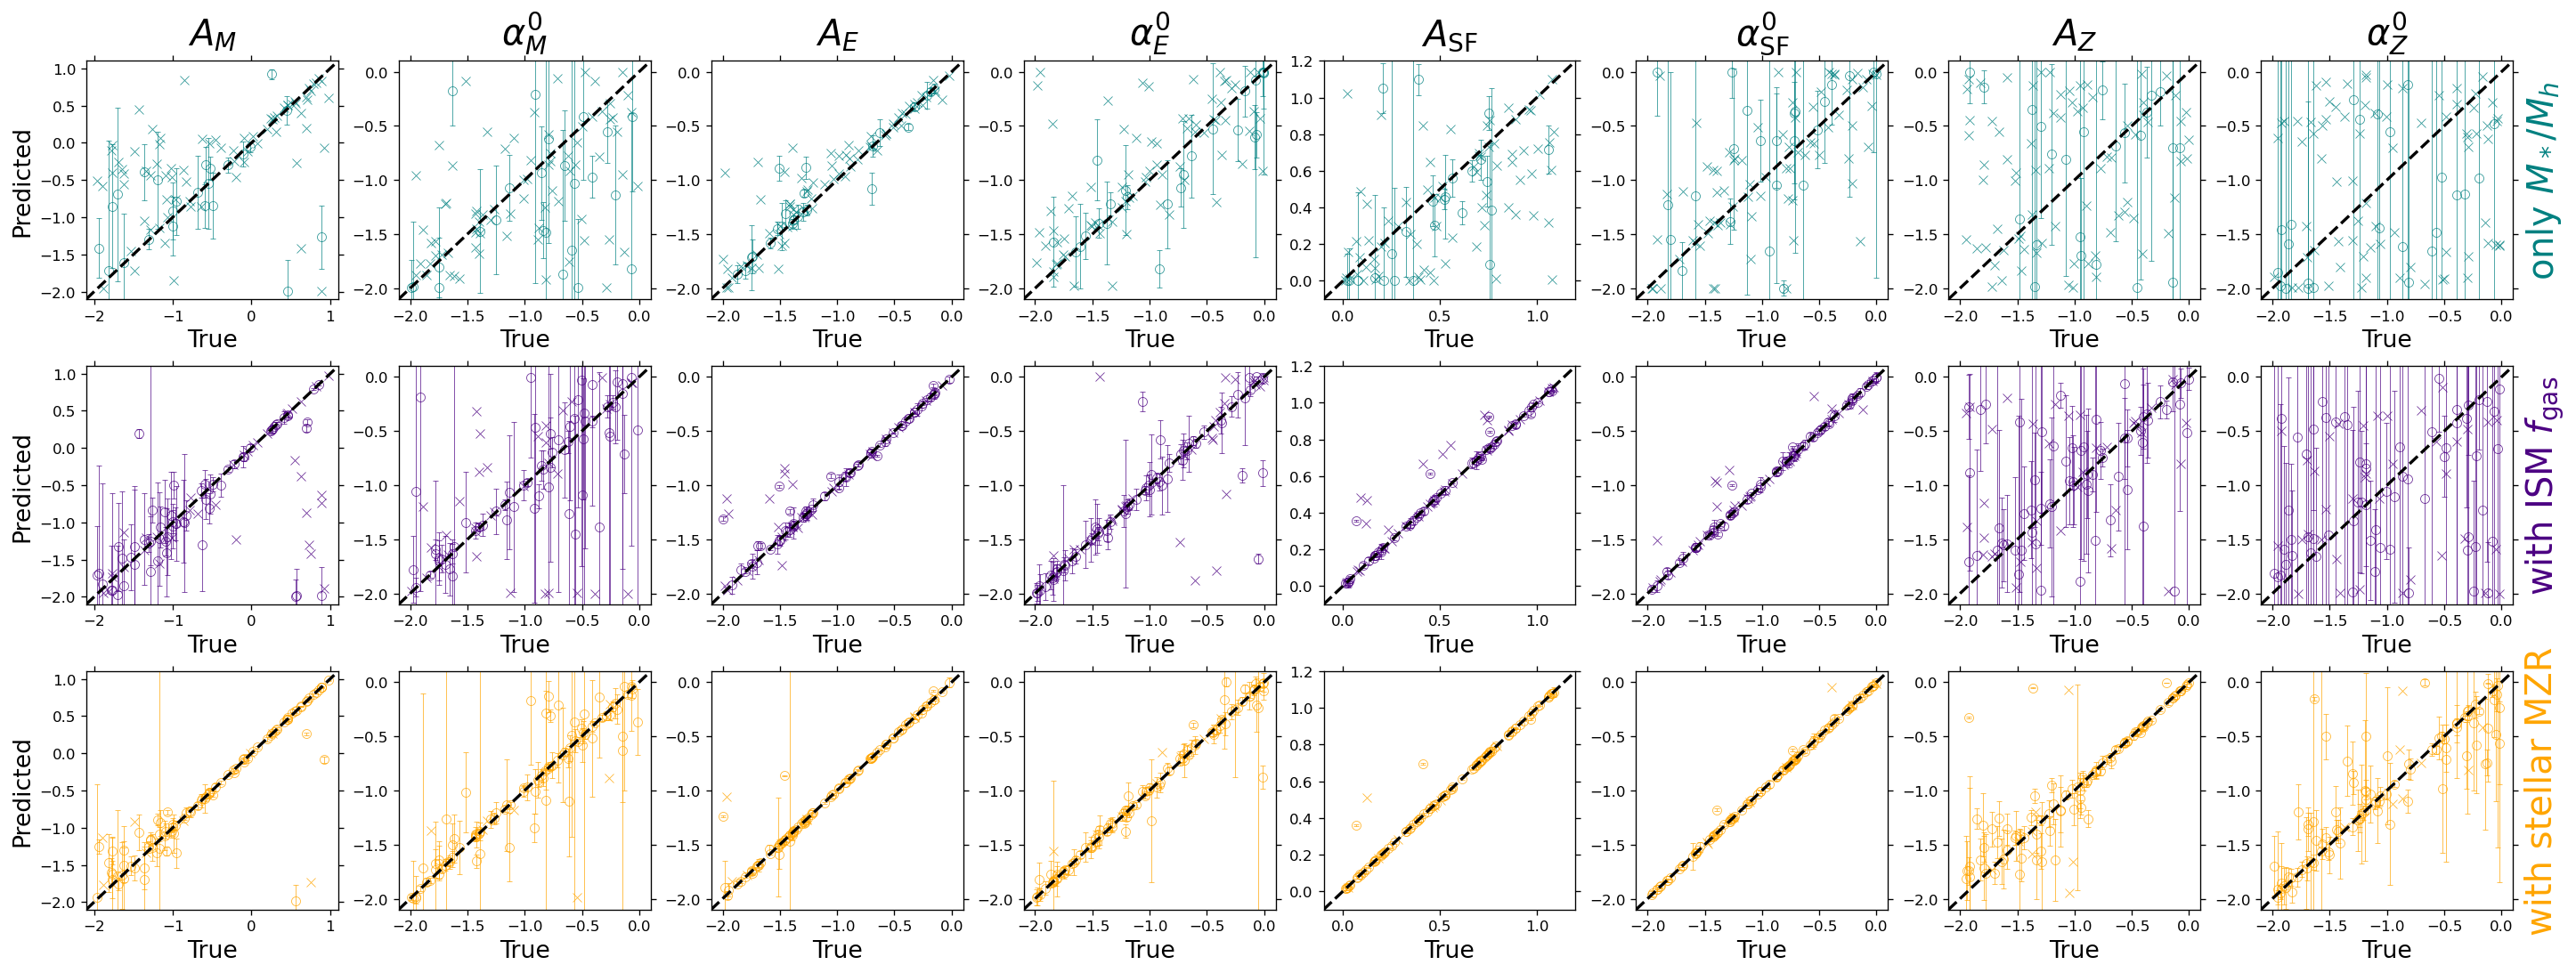

In [72]:
predicted_vs_true_parameters(constraint_results,constraint_labels,constraint_colors)

In [75]:

def percentile_fishers(sigmas):

    # apply mask 
    mask = np.isfinite(sigmas)
    masked_sigmas = sigmas[mask]

    # compute percentiles of maskd sigmas 
    p16_sigmas = jnp.nanpercentile(masked_sigmas,16,axis=0)
    p50_sigmas = jnp.nanpercentile(masked_sigmas,50,axis=0)
    p84_sigmas = jnp.nanpercentile(masked_sigmas,84,axis=0)
    
    return p16_sigmas, p50_sigmas, p84_sigmas   

print(percentile_fishers(constraint_results[1][:, 1, 0]))


(Array(0.04358179, dtype=float64), Array(0.22439588, dtype=float64), Array(0.65626791, dtype=float64))


In [78]:

def percentile_biases(mus,truths,sigmas_true):

    # accuracy/bias statistic 
    biases = (mus-truths)/(sigmas_true)
    
    # apply mask 
    mask = np.isfinite(sigmas_true) # should always be defined for truth but just in case
    masked_sigmas = sigmas_true[mask]
    masked_biases = biases[mask]
    
    # compute percentiles of masked sigmas 
    p16_biases = jnp.nanpercentile(masked_biases,16,axis=0)
    p50_biases = jnp.nanpercentile(masked_biases,50,axis=0)
    p84_biases = jnp.nanpercentile(masked_biases,84,axis=0)
    
    return p16_biases, p50_biases, p84_biases

print(percentile_biases(constraint_results[2][:, 0, 0],constraint_results[2][:, 2, 0],constraint_results[2][:, 3, 0]))

(Array(-0.60658287, dtype=float64), Array(0.08832809, dtype=float64), Array(0.51069768, dtype=float64))


In [82]:
def compute_f_fail(out_run):
    sigmas = out_run[:,1,:]
    Nfail = jnp.sum(~jnp.all(jnp.isfinite(sigmas),axis=1))
    return Nfail/len(sigmas)

compute_f_fail(constraint_results[0]),compute_f_fail(constraint_results[1]),compute_f_fail(constraint_results[2])

(Array(0.76, dtype=float64),
 Array(0.37, dtype=float64),
 Array(0.08, dtype=float64))

In [95]:
def fisher_cond(corr_matrices):
    
    conds = jnp.asarray([jnp.linalg.cond(corr_matrices[i]) for i in range(len(corr_matrices))])
    
    return jnp.nanpercentile(conds,16),jnp.nanpercentile(conds,50),jnp.nanpercentile(conds,84)

# testing 
[fisher_cond(constraint_corrs[i]) for i in range(len(constraint_corrs))]

[(Array(1962.43790053, dtype=float64),
  Array(4432.44954259, dtype=float64),
  Array(16633.20955569, dtype=float64)),
 (Array(161.61463613, dtype=float64),
  Array(895.70823475, dtype=float64),
  Array(2750.53872961, dtype=float64)),
 (Array(319.96356798, dtype=float64),
  Array(842.61886576, dtype=float64),
  Array(2708.93674348, dtype=float64))]

In [116]:
""" combined 4-panel summary statistics """

def coverage_summaries(constraint_results,constraint_labels,constraint_colors,constraint_flags,constraint_corrs):

    # Define x positions for the labels (parameters)
    xvals = np.arange(len(par_labels))
    
    ### TO DO: automate the figsize for different numbers of constraints/parameters
    fig, axes = plt.subplots(nrows=4,ncols=1,figsize=(6,8),constrained_layout=True,dpi=120)
    
    ax_precision = axes[0]
    ax_accuracy = axes[1]
    ax_fail = axes[2]
    ax_cond = axes[3]
    
    # TO DO: automate this for different # of constraints/parameters (or let user adapt on their own...)
    constraint_shift = {0: -0.2, 1: 0.0, 2: 0.2}  # SMHM, +fgas, +mzr
    
    ### precision and accuracy -- loop over each constraint type
    
    for constraint_num, constraint_flag in enumerate(constraint_flags):
    
        # extract this constraint's stuff
        constraint_result = constraint_results[constraint_num]
        constraint_label = constraint_labels[constraint_num]
        constraint_color = constraint_colors[constraint_num]
    
        # general x-shift between parameters for precision and accuracy subplots
        shift = constraint_shift[constraint_num] + 0.1
    
        ### loop over each parameter for precision and accuracy
        for j in range(constraint_result.shape[2]):
    
            ### precision (sigma_fisher)
            p16, p50, p84 = percentile_fishers(constraint_result[:, 1, j])
            ax_precision.errorbar(xvals[j] + shift, float(p50),
                                  yerr=[[p50 - p16], [p84 - p50]],
                                  fmt='-8',color=constraint_color,
                                  capsize=4, lw=1.5, alpha=0.8, mfc='none',
                                  ms=4, mew=0.5,label=constraint_label if j == 0 else '__none__')
    
            ### accuracy (bias) 
            p16, p50, p84 = percentile_biases(constraint_result[:, 0, j],constraint_result[:, 2, j],constraint_result[:, 3, j])
            ax_accuracy.errorbar(xvals[j] + shift, float(p50),
                                 yerr=[[p50 - p16], [p84 - p50]],
                                 fmt='-8',color=constraint_color,
                                 capsize=4, lw=1.5, alpha=0.8, mfc='none',
                                 ms=4, mew=0.5,label='__none__')
    
    ### precision and accuracy subplot labels, limits, etc. 
    
    # first common aesthetics for precision and accuracy
    for ax in [ax_precision,ax_accuracy]:
    
        ax.errorbar(par_labels,np.full(len(par_labels),0),alpha=0)
        ax.set_xticks(xvals)
        ax.set_xticklabels(par_labels, rotation=0,fontsize=12)
        ax.set_xlabel('Astrophysical Parameter',fontsize=12)
    
    ax_precision.legend(loc='lower left',fontsize=7,fancybox=True,framealpha=0,ncol=3,bbox_to_anchor=(0,-0.05))
    ax_precision.set_ylabel(r'$\mathcal{P}\;\left(\sigma_{\rm Fisher}\right)$',fontsize=14)
    ax_precision.set_yscale('log')
    ax_precision.set_ylim(1e-3,1e1)
    
    ax_accuracy.set_ylabel(r'$\mathcal{P}\;\left(\frac{\theta_{\rm MAP}-\theta_{\rm true}}{\sigma_{\rm Fisher}^{\rm true}}\right)$',
                           fontsize=14)
    ax_accuracy.set_yscale('symlog',linthresh=1e-1)
    ax_accuracy.set_ylim(-10, 10)
    ax_accuracy.axhline(0.0, color='k', ls='-', alpha=0.1, zorder=0, lw=3,label='__none__')
    ax_accuracy.axhspan(-1,1, facecolor='k', ls='-', alpha=0.1, zorder=0, lw=3,edgecolor='none',
                        label=r'$\pm1\sigma_{\rm Fisher}^{\rm true}$',)
    ax_accuracy.legend(loc='upper center',fontsize=10,fancybox=True,framealpha=0,bbox_to_anchor=(0.5,1.07))
    
    
    ### failure (saddle) rate
    constraint_f_fail = [compute_f_fail(constraint_results[i]) for i in range(len(constraint_results))]
    
    for constraint_num,constraint_color in enumerate(constraint_colors):
    
        ax_fail.plot(constraint_labels[constraint_num],constraint_f_fail[constraint_num],'8',
                     color=constraint_color,mfc='none',ms=8,mew=2)
    
    ax_fail.plot(list(constraint_labels),constraint_f_fail,'k--',lw=1,alpha=0.5) 
    
    ax_fail.set_ylim(-0.05,1.05)
    ax_fail.set_ylabel(r'$\mathscr{F}_{\rm \;saddle}^{\rm \;fail}$',fontsize=14)
    ax_fail.set_xlabel('Constraints',fontsize=12)
    ax_fail.tick_params(axis='x',labelsize=12)
    
    ### degeneracy strength (fisher matrix condition number)
    constraint_conds = [fisher_cond(constraint_corrs[i]) for i in range(len(constraint_corrs))]
    
    for constraint_num, constraint_color in enumerate(constraint_colors):
    
        cond = constraint_conds[constraint_num]
    
        ax_cond.errorbar(constraint_labels[constraint_num], cond[1],
                         yerr=[[cond[1]-cond[0]], [cond[2]-cond[1]]],
                         fmt='8', color=constraint_color, mfc='none', ms=8, mew=2)
    
    ax_cond.plot(constraint_labels,[constraint_conds[i][1] for i in range(3)],'k--',lw=1,alpha=0.5) # July 8
    ax_cond.tick_params(axis='x',labelsize=12)
    
    ax_cond.set_ylabel(r'$\kappa_{\rm Fisher}$', fontsize=14)
    ax_cond.set_xlabel('Constraints', fontsize=12)
    ax_cond.set_yscale('log')
    ax_cond.set_ylim(1e2,None)
    
    # Add a thick downward arrow using ax.arrow
    ax_cond.annotate('', xy=(0.05, 0.2), xytext=(0.05, 0.5), xycoords='axes fraction',
                     arrowprops=dict(arrowstyle='simple', color='gray', lw=2,))
    
    # Add the text to the right of the arrow
    ax_cond.text(0.1, 0.35,r'lower $\kappa_{\rm Fisher}$' + '\n' + r'$\Rightarrow$ weaker' + '\n' + r'degeneracies',
                 transform=ax_cond.transAxes,fontsize=11, color='gray', va='center')
    
    ax_cond.text(0.99,0.8,'16-50-84 percentiles of\nthe condition number of Fisher matrices',
                 transform=ax_cond.transAxes,fontsize=8,ha='right')

    # plt.savefig('figures_adam_autoflag/summary_fisher_errors_failures_conds_robust_CPU1000_only8par.png',bbox_inches='tight',dpi=300,facecolor='w')

    plt.savefig(os.path.join(output_path,'figures','coverage_adam_summaries.png'),
                bbox_inches='tight',dpi=300,facecolor='w')


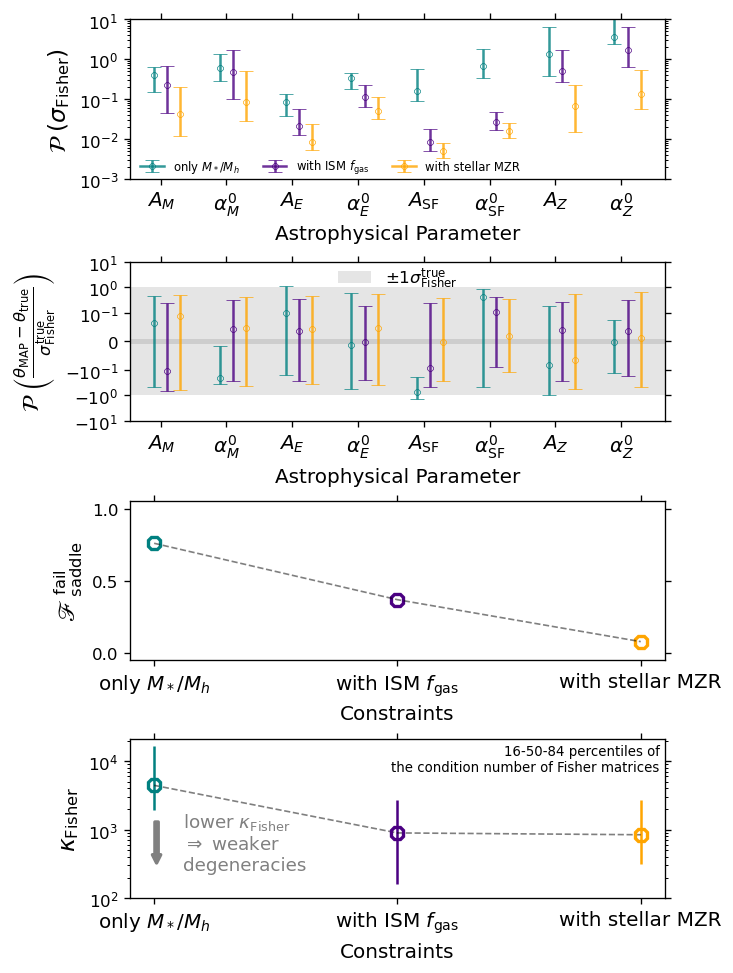

In [117]:
coverage_summaries(constraint_results,constraint_labels,constraint_colors,constraint_flags,constraint_corrs)

/mnt/home/vpandya/miniconda3/envs/jaxclone/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/jaxclone/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=100 in 0.883 sec


/mnt/home/vpandya/miniconda3/envs/jaxclone/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/jaxclone/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=110 in 0.514 sec


/mnt/home/vpandya/miniconda3/envs/jaxclone/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/mnt/home/vpandya/miniconda3/envs/jaxclone/lib/python3.12/site-packages/multiprocess/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


finished constraint_flag=111 in 0.519 sec
finished all runs in 1.916 sec


/mnt/ceph/users/vpandya/sapphire/sapphire/visualization/coverage_adam.py:226: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(par_labels, rotation=0,fontsize=12)
/mnt/ceph/users/vpandya/sapphire/sapphire/visualization/coverage_adam.py:226: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(par_labels, rotation=0,fontsize=12)


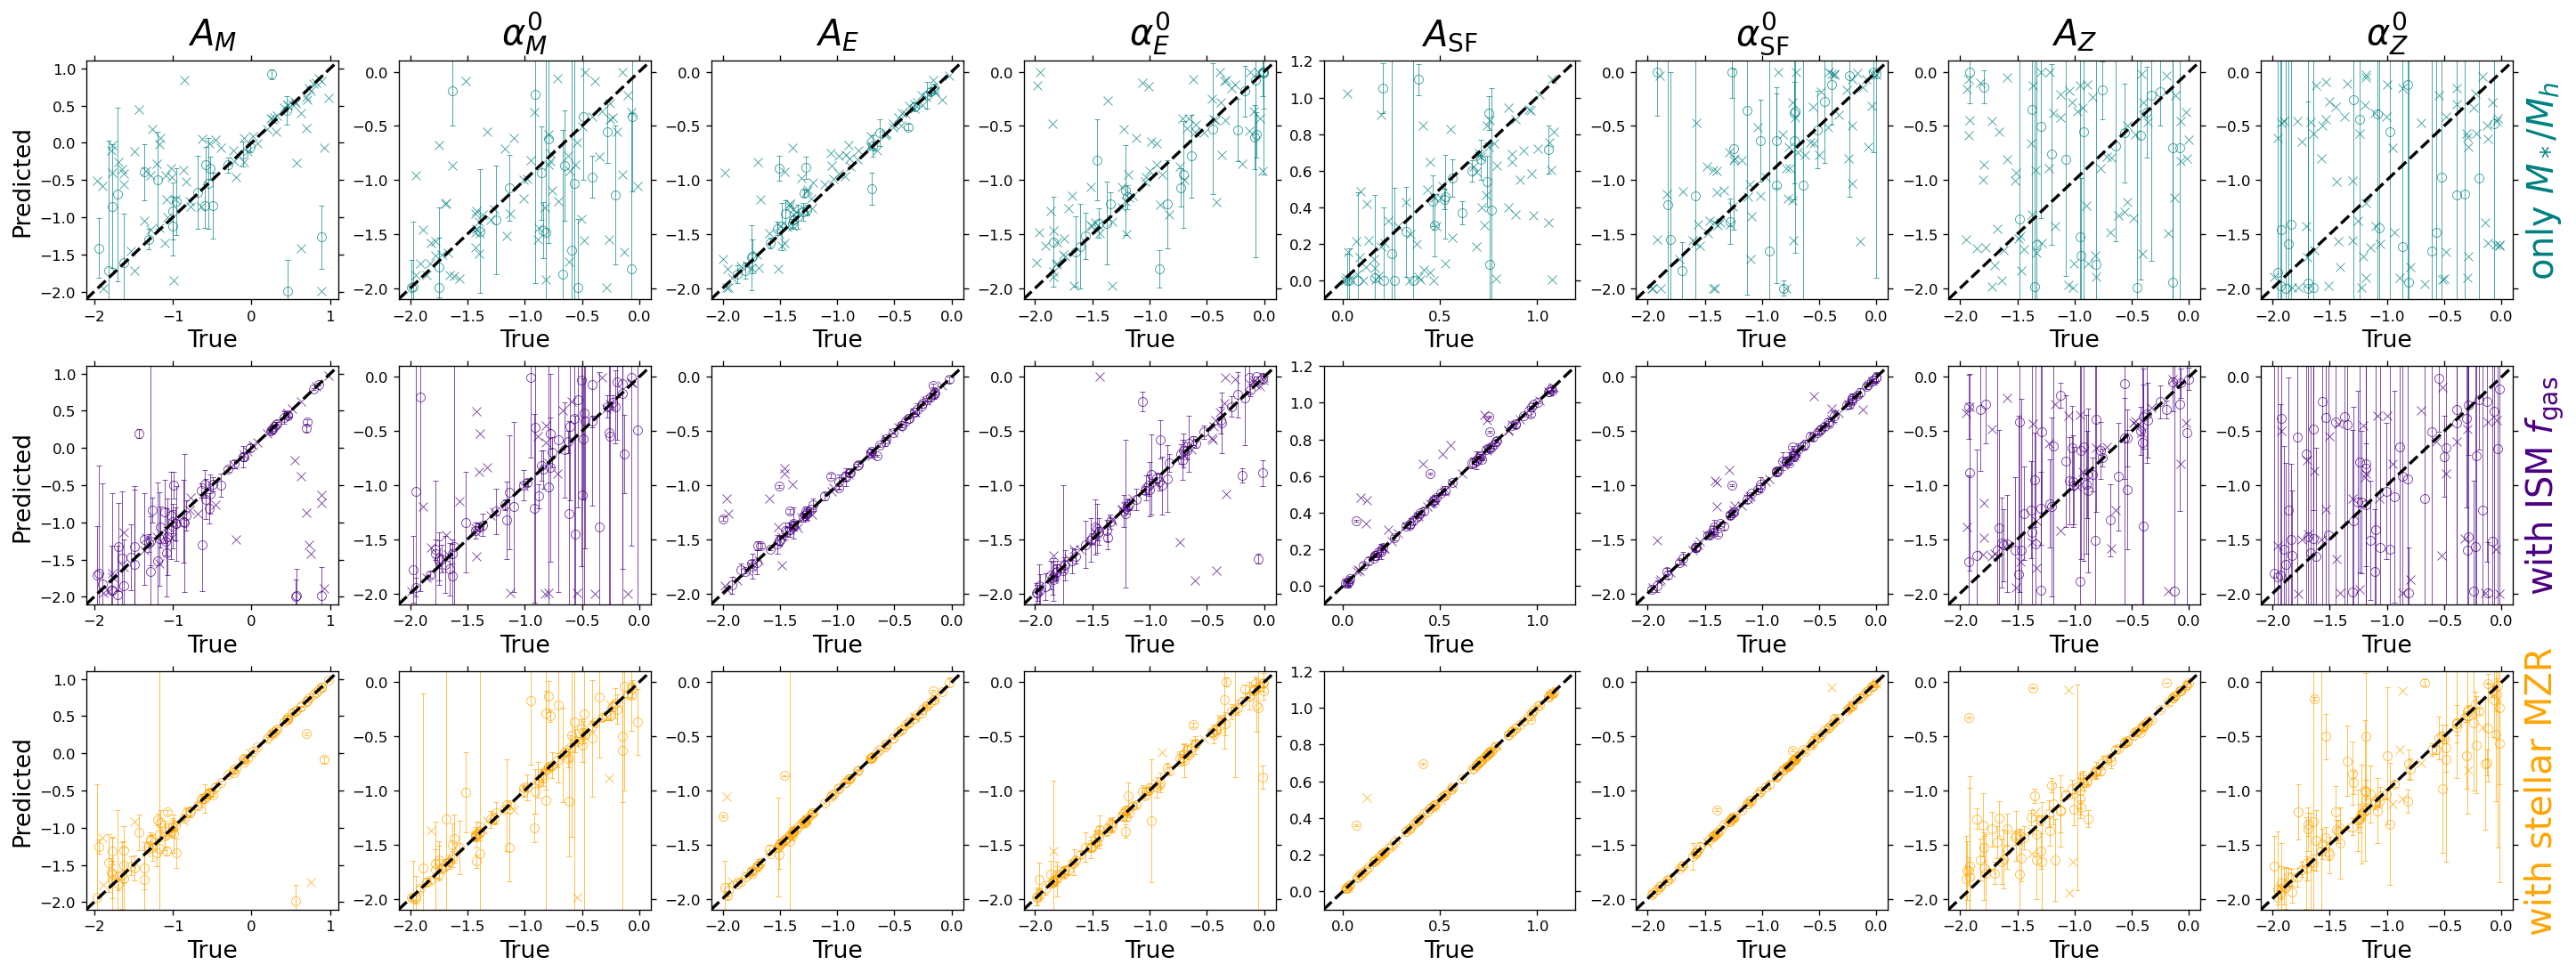

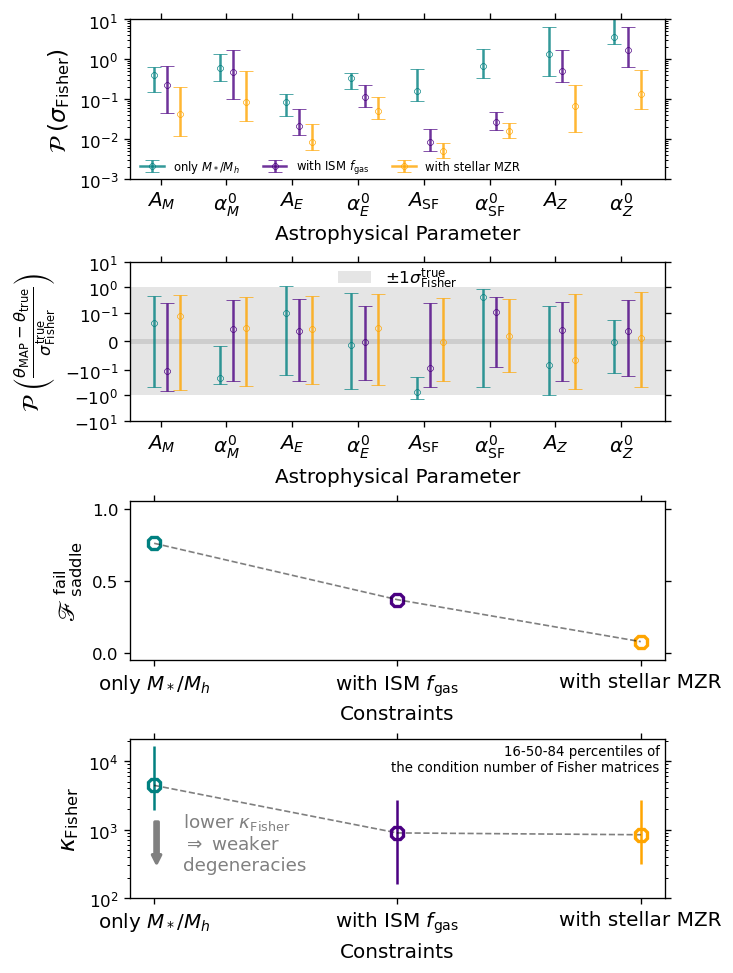

In [1]:
from sapphire import visualization
import jax.numpy as jnp

output_path = '/mnt/ceph/users/vpandya/sapphire_outputs'
mocknums = jnp.arange(100)
constraint_flags = ['100','110','111']
constraint_labels = [r'only $M_*/M_h$',r'with ISM $f_{\rm gas}$',r'with stellar MZR']
constraint_colors = ['teal','indigo','orange']
par_labels = [r'$A_M$',r'$\alpha_M^0$',r'$A_E$',r'$\alpha_E^0$',r'$A_{\rm SF}$',r'$\alpha_{\rm SF}^0$',r'$A_Z$',r'$\alpha_Z^0$']

visualization.adam_coverage.plot(output_path,mocknums,constraint_flags,constraint_labels,constraint_colors,par_labels,False)